# 3.2.2 特征值模态与矩阵传播

## 学习目标与先修知识

能从特征值（eigenvalue）与特征向量（eigenvector）建立模态（mode）解，区分慢快时间尺度（time scale）、初值（initial condition）激发与观测（observation）抵消，并连接矩阵（matrix）幂和矩阵指数（matrix exponential）。

先修：矩阵、线性方程、内积（inner product）投影（projection）与指数衰减。 [复习上一节](01-状态输入与观测映射.ipynb)。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

两室量都在变化，能否找到一些固定方向，使每个方向只按自己的速率缩小？为什么同一系统在某次观测里看上去只有一种衰减速度？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK = '#008bfb', '#ff0051'

## 初步实验

先计算一个具体情形，再解释这些数是怎样相互制约的。

In [2]:
M=np.array([[-.3,.2],[.2,-.3]])
for vector in [np.array([1,1]),np.array([1,-1])]:
    print('方向',vector,'乘 M 后',M@vector)

方向 [1 1] 乘 M 后 [-0.1 -0.1]
方向 [ 1 -1] 乘 M 后 [-0.5  0.5]


## 模型假设

本节特意采用对称模型（model）：两室以 a=.2/T 双向交换，**两个室各自**以 c=.1/T 清除，无输入（input）。与上一节仅第一室清除的模型不同。初值 [6,0] U。两状态（state）单位相同；共同、差异方向使用未归一化的 [1,1]、[1,−1]。

## 数学解释与推导

特征向量 v 是乘 M 后仍沿自身方向的非零向量（vector）：$Mv=\lambda v$，λ 是特征值。v 的长度可以改变；零向量不能定义一个方向。若令 $x(t)=z(t)v$，代入 $\dot x=Mx$ 得 $\dot z=\lambda z$，因此 $z(t)=z(0)e^{\lambda t}$。方向与随时间的幅度合在一起称为模态。

对当前矩阵
$$M=\begin{pmatrix}-a-c&a\\a&-a-c\end{pmatrix},$$
直接相乘给出 $v_s=(1,1)^\mathsf T,\lambda_s=-c$ 和 $v_f=(1,-1)^\mathsf T,\lambda_f=-(2a+c)$。从 $x_0=s v_s+d v_f$ 相加相减得到 $s=(A_1(0)+A_2(0))/2$、$d=(A_1(0)-A_2(0))/2$，所以
$$x(t)=s e^{-ct}v_s+d e^{-(2a+c)t}v_f.$$
本例 s=d=3 U。共同分量在 10 T 缩到原来的 e⁻¹；差异分量只需 2 T。两个室都含两种模态，不能将“第一个室”叫作慢模态。

一般二维矩阵可由 $\det(M-\lambda I)=0$ 找候选 λ，因为非零 v 满足 $(M-\lambda I)v=0$ 时该矩阵必奇异。若有完整的独立特征向量组，组成列矩阵 V，则 $M=V\Lambda V^{-1}$。计算系数应解 $Vz_0=x_0$；一般矩阵的特征向量不必正交（orthogonality），不能总用内积代替求解。

离散更新 $x_{n+1}=Px_n$ 反复代入给 $x_n=P^n x_0$，$P^0=I$。对于欧拉法（forward Euler method） $P=I+hM$，每个模态每步乘 $1+h\lambda$，连续系统的稳定不保证粗步长稳定。

连续传播定义矩阵指数
$$e^{Mt}=I+Mt+\frac{(Mt)^2}{2!}+\cdots.$$
各次幂是矩阵乘法（matrix multiplication）。逐项求导可得 $(e^{Mt})'=Me^{Mt}$，t=0 为 I，因而它满足传播方程与起点条件。可对角化时 $e^{Mt}=V\operatorname{diag}(e^{\lambda_i t})V^{-1}$。`np.exp` 是逐元素指数，**不**计算一般矩阵指数。

一个模态在观测中出现需要两件事：初值系数非零，而且 Cv 非零。[2,2] 没有激发差异模态；[6,0] 激发了它，但 C=[1,1] 又将其抵消。三者分别是系统具有某模态、此次实验激发它、所选观测能看见它。

## 核心实现

把刚才的关系逐项写入函数。

In [3]:
def symmetric_modes(a, c, initial, times):
    import math
    slow = (initial[0]+initial[1])/2
    fast = (initial[0]-initial[1])/2
    values = []
    for t in times:
        shared = slow*math.exp(-c*t)
        difference = fast*math.exp(-(2*a+c)*t)
        values.append([shared+difference, shared-difference])
    return [-c, -(2*a+c)], [slow, fast], values

def exponential_series(matrix,time,terms=50):
    # 仅用于本节有界小矩阵的独立级数核对，不是通用求解器。
    matrix=np.asarray(matrix,dtype=float)
    result=np.eye(len(matrix));term=result.copy()
    for n in range(1,terms):
        term=term@(matrix*time)/n
        result+=term
    return result

## 对照实验

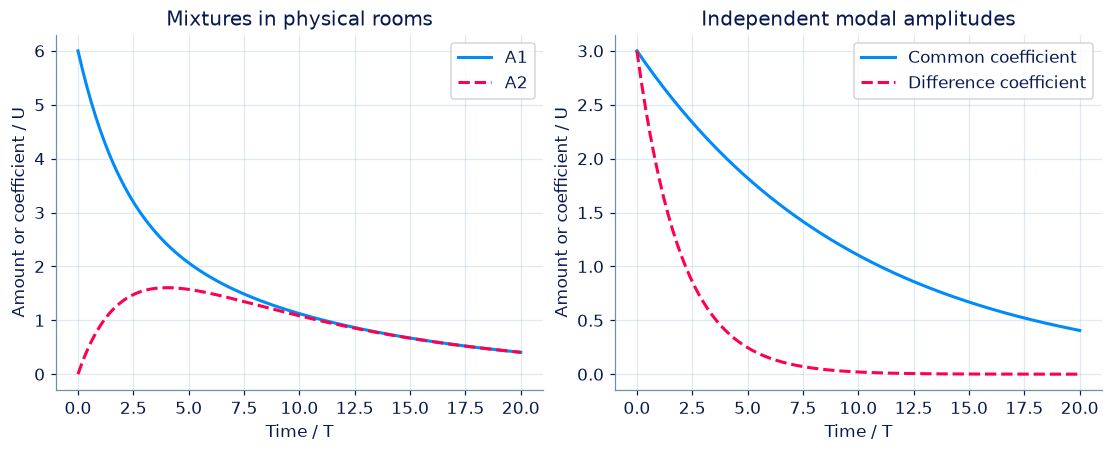

| 模态 | 特征值 / (1/T) | 初值系数 / U | 特征时间 / T |
| --- | --- | --- | --- |
| 共同 | -0.1 | 3 | 10 |
| 差异 | -0.5 | 3 | 2 |

In [4]:
times=np.linspace(0,20,201)
eigenvalues,coefficients,states=symmetric_modes(.2,.1,[6,0],times)
states=np.array(states)
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].plot(times,states[:,0],color=BLUE,label='A1');axes[0].plot(times,states[:,1],'--',color=PINK,label='A2')
axes[1].plot(times,3*np.exp(-.1*times),color=BLUE,label='Common coefficient')
axes[1].plot(times,3*np.exp(-.5*times),'--',color=PINK,label='Difference coefficient')
for ax,title in zip(axes,['Mixtures in physical rooms','Independent modal amplitudes']):
    ax.set(xlabel='Time / T',ylabel='Amount or coefficient / U',title=title);ax.legend()
plt.show()
display(Markdown(show_table(['模态','特征值 / (1/T)','初值系数 / U','特征时间 / T'],[('共同',-.1,3,10),('差异',-.5,3,2)])))

## 结果解释

第一室早期下降较快，第二室先接收交换来的物质；后期差异模态衰减，两个室靠近同一种慢衰减。模态方向是解释工具，物理室中的曲线是它们的叠加。

### 独立核对

用独立的和、差标量方程和有界矩阵级数检查模态重建。库返回的特征值没有固定顺序，特征向量还可能反号，比较方程残差（residual）比比较原始列顺序稳妥。

In [5]:
values,vectors=np.linalg.eig(M)
np.testing.assert_allclose(M@vectors,vectors@np.diag(values),atol=1e-12)
for t in [0,.5,2]:
    direct=symmetric_modes(.2,.1,[6,0],[t])[2][0]
    np.testing.assert_allclose(exponential_series(M,t)@[6,0],direct,atol=1e-12)
np.testing.assert_allclose(states.sum(axis=1),6*np.exp(-.1*times))
np.testing.assert_allclose(states[:,0]-states[:,1],6*np.exp(-.5*times))
P=np.eye(2)+.1*M;x=np.array([6.,0.])
for _ in range(10):x=P@x
np.testing.assert_allclose(x,np.linalg.matrix_power(P,10)@[6,0])
assert symmetric_modes(.2,.1,[2,2],[0])[1][1]==0
print('模态残差、独立矩阵级数、和差方程与离散矩阵幂核对通过。')

模态残差、独立矩阵级数、和差方程与离散矩阵幂核对通过。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/03-02-线性状态空间与动态模态/explore/)：改变一个条件，观察时间曲线与状态空间（state space）中的运动，再回到本节解释。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：分解共同衰减与室间差异

两室以相同系数 a 双向交换，并且两个室都以系数 c 清除，无输入（input）。矩阵（matrix） M=[[-a-c,a],[a,-a-c]]。用慢模态（mode） [1,1] 和快模态 [1,−1] 求精确状态（state）。

**函数与代码模板**

```python
def solve(
    a: float,
    c: float,
    initial: list[float],
    times: list[float],
) -> tuple[list[float], list[float], list[list[float]]]:
    # 根据题意计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `a` | `float` | 双向交换系数。 | 1/T |
| `c` | `float` | 每个室各自的清除系数（elimination rate constant）。 | 1/T |
| `initial` | `list[float]` | [A1(0),A2(0)]。 | U |
| `times` | `list[float]` | 所求时刻，依给定顺序返回。 | T |

**返回值**

按以下顺序返回元组：(eigenvalues, coefficients, states)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `eigenvalues` | `list[float]` | 慢、快顺序的两个特征值（eigenvalue）。 | 1/T |
| `coefficients` | `list[float]` | 上述两个指定特征向量（eigenvector）的系数，不将向量（vector）归一化。 | U |
| `states` | `list[list[float]]` | 每个时刻一行 [A1,A2]。 | U |

**计算规则**

λslow=−c，λfast=−(2a+c)；s=(A1(0)+A2(0))/2，d=(A1(0)−A2(0))/2；x(t)=s exp(−ct)[1,1]+d exp(−(2a+c)t)[1,−1]。

**约束与边界**

- 所有数值有限；不修改输入列表。
- 0≤a,c≤1；initial 长度 2，各项 0—20；times 长度 1—30，各项 0—20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| a | 双向交换系数。 | 0.2 | 1/T |
| c | 每个室各自的清除系数（elimination rate constant）。 | 0.1 | 1/T |
| initial | [A1(0),A2(0)]。 | [6, 0] | U |
| times | 所求时刻，依给定顺序返回。 | [0, 2] | T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
a = 0.2
c = 0.1
initial = [6, 0]
times = [0, 2]

result = solve(a, c, initial, times)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| eigenvalues | 慢、快顺序的两个特征值（eigenvalue）。 | [-0.1, -0.5] | 1/T |
| coefficients | 上述两个指定特征向量（eigenvector）的系数，不将向量（vector）归一化。 | [3.0, 3.0] | U |
| states | 每个时刻一行 [A1,A2]。 | [[6.0, 0.0], [3.5598305827482726, 1.3525539357196186]] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([-0.1, -0.5],
                   [3.0, 3.0],
                   [[6.0, 0.0],
                    [3.5598305827482726,
                     1.3525539357196186]])
```

**样例解释**

特征值为 [−0.1,−0.5] /T，两个系数均为 3 U；t=0 两个模态相加还原 [6,0]。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：分解共同衰减与室间差异](http://127.0.0.1:8000/chapters/03-02-%E7%BA%BF%E6%80%A7%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81/practice/?question=p03-symmetric-modes)

### 第 2 题 · 单项选择题：模态存在但未被激发

上述对称交换模型（model） a>0，初值（initial condition） [2,2]。差异模态（mode） [1,−1] 的特征值（eigenvalue）仍存在，但其轨迹（trajectory）贡献为零。原因是？

- **A.** 该初值在差异模态方向的系数为零。
- **B.** 所有快速模态都不存在。
- **C.** 两室矩阵（matrix）没有特征值。
- **D.** 观测（observation）曲线为零就能证明矩阵为零。

[作答：模态存在但未被激发](http://127.0.0.1:8000/chapters/03-02-%E7%BA%BF%E6%80%A7%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81/practice/?question=p03-unexcited-mode)

### 第 3 题 · 多项选择题：被求和隐藏的模态

慢向量（vector） [1,1]、快向量 [1,−1]，初值（initial condition） [6,0]，观测（observation） C=[1,1]。哪些成立？

- **A.** 两个模态（mode）均被初值激发。
- **B.** C[1,−1]=0，因此快模态在此观测中抵消。
- **C.** 快模态在完整状态（state）中也不存在。
- **D.** 换 C=[1,0] 能在该初值下看到两种衰减。

[作答：被求和隐藏的模态](http://127.0.0.1:8000/chapters/03-02-%E7%BA%BF%E6%80%A7%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81/practice/?question=p03-invisible-mode)

### 第 4 题 · 多项选择题：连续传播与逐元素指数

一般矩阵（matrix） M 的连续传播是 exp(Mt)。以下哪些正确？

- **A.** 定义中的幂是矩阵乘法（matrix multiplication）幂。
- **B.** 通常可以直接用 np.exp(M*t) 得到矩阵指数（matrix exponential）。
- **C.** 若 M=VΛV⁻¹ 且 V 可逆，可写成 V exp(Λt)V⁻¹。
- **D.** 离散更新矩阵 P 的 n 步传播是 Pⁿ。

[作答：连续传播与逐元素指数](http://127.0.0.1:8000/chapters/03-02-%E7%BA%BF%E6%80%A7%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81/practice/?question=p03-matrix-exponential)

### 第 5 题 · 单项选择题：哪一个变化更慢

两个实特征值（eigenvalue）为 −0.1/T 和 −0.5/T。仅考虑各模态（mode）自身衰减，正确结论是？

- **A.** 特征时间（characteristic time）分别为 10 T 和 2 T。
- **B.** −0.5 对应更慢的模态。
- **C.** 特征值为负说明所追踪物质总量（tracked amount）必须负。
- **D.** 每个模态都在特征时间时恰好变为零。

[作答：哪一个变化更慢](http://127.0.0.1:8000/chapters/03-02-%E7%BA%BF%E6%80%A7%E7%8A%B6%E6%80%81%E7%A9%BA%E9%97%B4%E4%B8%8E%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81/practice/?question=p03-modal-time)

**进一步阅读**

[MIT 一阶系统课程](https://ocw.mit.edu/courses/18-03sc-differential-equations-fall-2011/pages/unit-iv-first-order-systems/)：矩阵方法、矩阵指数、相图与线性化。 [NumPy eig 文档](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html)：列向量约定、顺序与可对角化的限制。